In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm_notebook as tqdm

import warnings
warnings.filterwarnings('ignore')

In [2]:
file_path = r'C:\Users\Yahea al\Desktop\kaggle_ComputerVision\data\plant-pathology-2020-fgvc7\images'
train_df=pd.read_csv(r'C:\Users\Yahea al\Desktop\kaggle_ComputerVision\data\plant-pathology-2020-fgvc7\train.csv')
train_df['image_id']=train_df['image_id'] 
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0


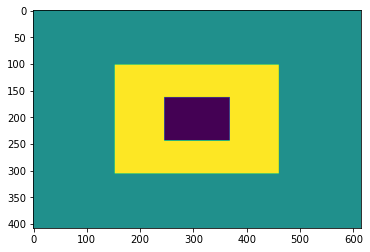

In [3]:
def init_grabcut_mask(h, w):
    mask = np.ones((h, w), np.uint8) * cv2.GC_PR_BGD
    mask[h//4:3*h//4, w//4:3*w//4] = cv2.GC_PR_FGD
    mask[2*h//5:3*h//5, 2*w//5:3*w//5] = cv2.GC_FGD
    return mask

plt.imshow(init_grabcut_mask(3*136, 3*205));

In [4]:
def load_image(image_id):
    filename = image_id + ".jpg"
    image = cv2.imread(os.path.join(file_path , filename))
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def remove_background(image):
    h, w = image.shape[:2]
    mask = init_grabcut_mask(h, w)
    bgm = np.zeros((1, 65), np.float64)
    fgm = np.zeros((1, 65), np.float64)
    cv2.grabCut(image, mask, None, bgm, fgm, 1, cv2.GC_INIT_WITH_MASK)
    mask_binary = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
    result = cv2.bitwise_and(image, image, mask = mask_binary)
    return result

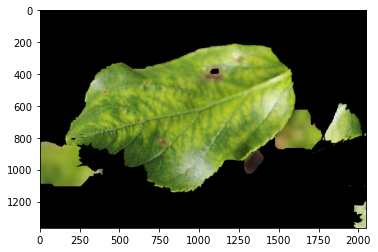

In [5]:
plt.imshow(remove_background(plt.imread(os.path.join(file_path,train_df.image_id[0]+'.jpg'))))